# CTD Data Extraction — Barkley Sound

A **CTD** (Conductivity–Temperature–Depth) instrument measures seawater properties as it is lowered through the water column.  
This notebook loads raw CTD casts collected in **Barkley Sound** (Bamfield Marine Sciences Centre, British Columbia) using an **AML-6 CTD**.

For each cast we extract only the **downcast** — the portion of the record while the instrument is descending — and then visualise the profiles and a temperature–salinity (T-S) diagram.

---
**To get started:** set `DATE_PATTERNS` in the `USER CONFIGURATION` cell to match the date(s) of your casts (the same value used in the download notebook), then run all cells in order (`Kernel → Restart & Run All`).

In [23]:
# Package installation — uncomment and run this cell if you receive an ImportError.
# After installing, re-run this cell and then re-run the imports cell below.

# !pip install numpy pandas matplotlib cmocean seaborn gsw netCDF4 cartopy

In [24]:
# Numerical / data
import numpy as np
import pandas as pd

# Plotting
from matplotlib import pyplot as plt
from matplotlib.colors import Normalize
import cmocean          # perceptually-uniform oceanographic colormaps
import seaborn as sns

# Oceanographic calculations
import gsw              # TEOS-10 Gibbs SeaWater toolbox

# Mapping
import cartopy
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# File handling
import glob, os
from netCDF4 import Dataset as netcdf_dataset

In [84]:
from pathlib import Path

# ── USER CONFIGURATION ──────────────────────────────────────────
# Parent directory containing your CTD Data folder (must match the download notebook).
SAVE_DIR = Path.home() / 'Documents'

# Name of the CTD Data folder (must match the download notebook).
FOLDER_NAME = 'CTD Data'

# Date(s) of the casts to process (format: YYYY-MM-DD, must match the download notebook).
# To combine multiple days into a single dataset, add more entries to the list, e.g.:
#   DATE_PATTERNS = ['2026-05-04', '2026-05-05']
DATE_PATTERNS = ['2026-05-11']#['2026-05-04', '2026-05-05', '2026-05-07', '2026-05-08', '2026-05-09', '2026-05-11']


FILETYPE   = 'aml'
BATHY_FILE = 'barkley_sound_1_navd88_2016.nc'

# Minimum depth (m) at which a cast is considered to have started descending.
# Rows above this depth at the start of a file are treated as the soak period.
SURFACE_THRESHOLD = 1.0

# Dissolved oxygen unit conversion: AML records DO in µmol/L.
# Divide by this factor to convert to mL/L (legacy unit).
DO_CONV = 43.57

# Dissolved oxygen display units.
# Set to 'umol/L' (modern standard) or 'mL/L' (legacy unit).
DO_UNITS = 'umol/L'

# T-S diagram colour variable.
# Options: 'DO', 'depth', 'Turbidity', 'sigma0', 'pH', 'cDOM'
TS_COLOR = 'Turbidity'

# Set to True to use a different marker shape for each date on the T-S diagram.
# Only has an effect when DATE_PATTERNS contains more than one date.
TS_MARKER_BY_DAY = True

# Instrument sampling rate (Hz) and smoothing window for the CTD Profiles plot.
# SMOOTH_WINDOW_S = 0  → no smoothing (raw 20 Hz data)
# SMOOTH_WINDOW_S = 1  → 1-second rolling mean (20 samples at 20 Hz)
SAMPLE_RATE_HZ  = 20
SMOOTH_WINDOW_S = 1

# Set to True to label each station marker and profile line with the cast time (HH:MM).
LABEL_BY_TIME = True

# Outlier bounds — sensor glitches that produce physically impossible values are
# replaced with NaN so they do not distort axis scales or derived quantities.
# Values outside [lo, hi] for each variable are set to NaN; the row is kept so
# depth profiles remain continuous.  Set a bound to None to skip that variable.
OUTLIER_BOUNDS = {
    'Salinity': (0, 42),    # PSU  — practical salinity range for seawater
    'TempCT':   (-2, 35),   # °C   — in-situ temperature
    'DO':       (0, 600),   # µmol/L
    'pH':       (6, 9),
}
# ────────────────────────────────────────────────────────────────

DATA_DIRS = [str(SAVE_DIR / FOLDER_NAME / p) for p in DATE_PATTERNS]

_multi_date = len(DATE_PATTERNS) > 1

def _cast_label(file_path, index):
    if not LABEL_BY_TIME:
        return str(index)
    _bn = os.path.basename(file_path)
    _time = _bn[-12:-4][:5].replace('-', ':')
    return f"{_bn[-23:-13][5:]} {_time}" if _multi_date else _time

# Derived from DO_UNITS — no need to edit below this line
DO_DIVISOR = DO_CONV if DO_UNITS == 'mL/L' else 1.0
DO_LABEL   = 'DO (mL L⁻¹)' if DO_UNITS == 'mL/L' else 'DO (µmol L⁻¹)'

for _d in DATA_DIRS:
    print(f'Data directory : {_d}')

Data directory : /Users/hjb62/Documents/CTD Data/2026-05-11


## File Discovery

The cell below scans each folder in `DATA_DIRS` for all `.aml` files and sorts them chronologically by the full timestamp embedded in each filename.  
The result is `file_list` — an ordered list of file paths, one per cast.

In [83]:
def grab_time(x):
    return os.path.basename(x)[-23:-4]  # full YYYY-MM-DD_HH-MM-SS for cross-day sorting

file_list = []
for _d in DATA_DIRS:
    file_list.extend(glob.glob(os.path.join(_d, f'*.{FILETYPE}')))
file_list = sorted(file_list, key=grab_time)

print(f'Found {len(file_list)} cast files.')

Found 59 cast files.


## Importing and Trimming Casts

`importfiles` reads each raw AML file, parses the header to extract GPS coordinates and column names, then trims each cast to its **downcast** only.

**Trimming logic:** before a cast begins, the instrument rests near the surface (the *soak period*).  
We locate the last moment the depth was less than `SURFACE_THRESHOLD` metres before the deepest point, and keep only data from that moment through the maximum depth.

The diagnostic plot in the next cell shows each cast **before** (top) and **after** (bottom) trimming.

In [31]:
def conv_float(x):
    """Convert a string to float, returning NaN if the string is not numeric."""
    return float(x) if (x.replace('.', '', 1).isdigit() or x.lstrip('-').replace('.', '', 1).isdigit()) else float('nan')


def importfiles(file_list, filetype, surface_threshold=2.0):
    """
    Import CTD cast files and trim each record to the downcast only.

    Parameters
    ----------
    file_list : list of str
        Ordered list of file paths returned by the file discovery cell.
    filetype : str
        Instrument file format. Currently only 'aml' is supported.
    surface_threshold : float
        Depth (m) below which the instrument is considered to have left the
        surface. Rows shallower than this at the start of the file are treated
        as the soak period and discarded. Default: 2.0 m.

    Returns
    -------
    df : pd.DataFrame
        All casts concatenated into a single DataFrame (useful for T-S plots).
    dfs : list of pd.DataFrame
        One DataFrame per cast, trimmed to the downcast.
    sample_lons : list of float
        GPS longitude for each cast (NaN if GPS lock was unavailable).
    sample_lats : list of float
        GPS latitude for each cast (NaN if GPS lock was unavailable).
    """
    if filetype == 'aml':
        fig, axs = plt.subplots(nrows=2, figsize=(6, 8), sharex=False)
        axs[0].set_title('Full records')
        axs[1].set_title('Trimmed downcasts')

        dfs = []
        sample_lons = [None] * len(file_list)
        sample_lats = [None] * len(file_list)

        for profile_idx, filepath in enumerate(file_list):
            nameline = np.nan
            header   = np.nan
            units    = []

            # AML files are not plain CSV — they start with a plain-text header
            # followed by the data block. We scan the header line-by-line to find:
            #
            #   MeasurementMetadata → announces the column names block;
            #                         column names are on the very next line,
            #                         units are on the line after that.
            #   MeasurementData     → the line number where the CSV data begins;
            #                         passed to pd.read_csv as the header row.
            #   GPSLatitude/Longitude → station coordinates recorded at cast time.
            with open(filepath) as fh:
                for i, line in enumerate(fh):
                    if 'MeasurementMetadata' in line:
                        nameline = i
                    elif 'MeasurementData' in line:
                        header = i
                    elif i == nameline + 1:
                        cols = line.strip().split('=', 1)[1].split(',')
                    elif i == nameline + 2:
                        units = [u.strip() for u in line.strip().split('=', 1)[1].split(',')]
                    elif 'GPSLatitude' in line:
                        lat_str = line.split('=', 1)[1].strip()
                    elif 'GPSLongitude' in line:
                        lon_str = line.split('=', 1)[1].strip()

            # Print column names and units from the first file as a sanity check.
            if profile_idx == 0 and units:
                print('Columns and units (from first file header):')
                for col, unit in zip(cols, units):
                    print(f'  {col}: {unit}')

            sample_lons[profile_idx] = conv_float(lon_str)
            sample_lats[profile_idx] = conv_float(lat_str)

            # Read the data block. pd.read_csv uses `header` as the row containing
            # column names; we supply our own names parsed above.
            data = pd.read_csv(filepath, header=header, names=cols)
            data['file']    = filepath.split('log_')[-1].split('_')[-1].split('.')[0]
            data['profile'] = profile_idx

            axs[0].plot(data['Depth'].values)

            # --- Trim to the downcast ---
            # Before each cast the instrument rests near the surface (the soak
            # period). We want only the descent from the moment it leaves the
            # surface down to its maximum depth, discarding both the soak period
            # and any upcast data recorded afterwards.

            # Step 1: find the index of the deepest measurement in this cast.
            maxdepth_idx = data['Depth'].idxmax()

            # Step 2: look only at rows before that deepest point, and find the
            # last row where the instrument was still within surface_threshold of
            # the surface. That row is where the real descent starts.
            pre_max      = data.loc[:maxdepth_idx]
            near_surface = pre_max[pre_max['Depth'] < surface_threshold]
            cast_start   = near_surface.index[-1] if len(near_surface) > 0 else pre_max.index[0]

            # Step 3: keep only the rows from cast_start to maxdepth_idx.
            data = data.loc[cast_start:maxdepth_idx].copy()

            axs[1].plot(data['Depth'].values, label=profile_idx)
            dfs.append(data)

        for ax in axs:
            ax.set_ylabel('Depth (m)')
            ax.invert_yaxis()

        # Combine all individual cast DataFrames into one for whole-dataset
        # calculations (T-S diagrams, oxygen saturation, etc.).
        df = pd.concat(dfs, ignore_index=True)
        return df, dfs, sample_lons, sample_lats

## Running the Import

The cell below calls `importfiles` on all files in `file_list` and produces a diagnostic plot showing each cast **before** (top panel) and **after** (bottom panel) trimming to the downcast.

Columns and units (from first file header):
  Date: yyyy-mm-dd
  Time: hh:mm:ss.ss
  Cond: mS/cm
  TempCT: C
  DOM: ppb
  Turbidity: NTU
  DO: umol/l
  TempDO: C
  pH: pH
  Pressure: dBar
  Salinity: PSU
  Density: kg/cm3
  CalcSV: m/s
  Depth: m


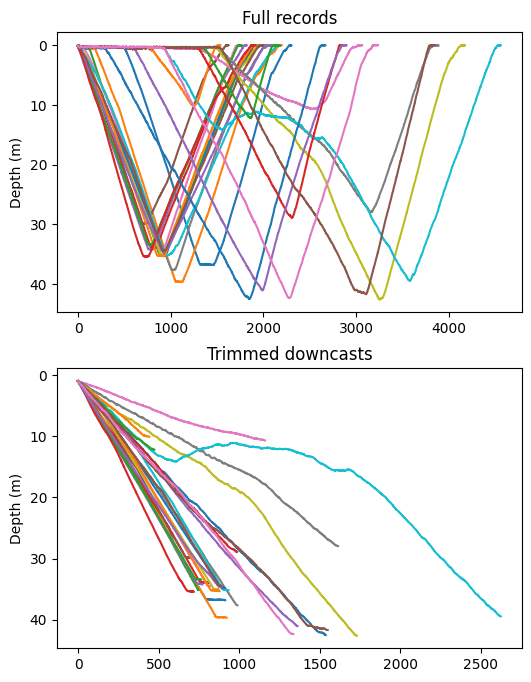

In [32]:
df, dfs, sample_lons, sample_lats = importfiles(file_list, FILETYPE, surface_threshold=SURFACE_THRESHOLD)

# Colour palette — one colour per profile, consistent across all figures.
PROFILE_COLORS = sns.color_palette('Spectral', n_colors=df['profile'].nunique())

In [33]:
# Apply outlier bounds: values outside the configured range are set to NaN.
# Rows are kept (not dropped) so depth profiles remain continuous.
_n_flagged = 0
for _col, (_lo, _hi) in OUTLIER_BOUNDS.items():
    if _col not in df.columns:
        continue
    _mask = (df[_col] < _lo) | (df[_col] > _hi)
    _n    = _mask.sum()
    if _n > 0:
        print(f'  {_col}: {_n} value(s) outside [{_lo}, {_hi}] → set to NaN')
        df.loc[_mask, _col] = np.nan
        _n_flagged += _n
if _n_flagged == 0:
    print('No outliers flagged.')
else:
    print(f'\n{_n_flagged} value(s) total set to NaN.')

No outliers flagged.


The GPS coordinates parsed from each file header are printed below.  
Any `nan` values indicate casts where the instrument did not acquire a GPS fix; those stations are omitted from the map.

In [34]:
print(sample_lons, sample_lats)

[-125.13737, -125.13775, -125.13733, -125.13699, -125.13724, -125.13693, -125.13737, -125.13718, -125.13734, -125.13716, -125.1373, -125.13715, -125.13734, -125.13721, -125.13747, -125.13727, -125.13637, -125.13643, -125.1376, -125.13823, -125.14062, -125.12701, -125.13593, -125.13665, -125.13732, -125.13824, -125.1403] [48.8381, 48.83953, 48.83768, 48.83961, 48.83775, 48.83969, 48.83768, 48.83959, 48.83767, 48.83954, 48.83766, 48.8395, 48.8377, 48.83958, 48.83771, 48.83953, 48.83617, 48.83815, 48.84036, 48.84195, 48.84403, 48.83088, 48.83573, 48.83816, 48.84023, 48.8419, 48.84417]


## TEOS-10 Derived Quantities

The raw AML data uses legacy units: **Practical Salinity** (S_P, dimensionless) and **in-situ temperature** (°C, ITS-90).  
The TEOS-10 standard (IOC 2010) recommends **Absolute Salinity** (S_A, g kg⁻¹) and **Conservative Temperature** (Θ, °C) for all thermodynamic calculations, as these are true conserved quantities under mixing.

The cell below converts to TEOS-10 and adds the following columns to `df`:

| Column | Description |
|--------|-------------|
| `p` | Pressure (dbar), computed from depth and latitude |
| `SA` | Absolute Salinity (g kg⁻¹) |
| `CT` | Conservative Temperature (°C) |
| `sigma0` | Potential density anomaly σ₀ (kg m⁻³), referenced to 0 dbar |

For any cast where GPS lock was unavailable, `SA`, `CT`, and `sigma0` will be `NaN`.

In [35]:
# Attach GPS coordinates to every row by mapping profile index → lat/lon.
# This is needed because gsw functions require position for accurate results.
lat_map = {i: lat for i, lat in enumerate(sample_lats)}
lon_map = {i: lon for i, lon in enumerate(sample_lons)}
df['lat'] = df['profile'].map(lat_map)
df['lon'] = df['profile'].map(lon_map)

# gsw.p_from_z uses the oceanographic sign convention: z is positive upward,
# so depth (positive downward) must be negated before passing it in.
df['p'] = gsw.p_from_z(-df['Depth'], df['lat'])

# Absolute Salinity (S_A, g/kg) from Practical Salinity (S_P, dimensionless).
# S_A accounts for regional variations in the composition of seawater; in the
# North Pacific it is slightly higher than S_P for the same sample.
df['SA'] = gsw.SA_from_SP(df['Salinity'], df['p'], df['lon'], df['lat'])

# Conservative Temperature (Θ, °C) from in-situ temperature.
# Unlike in-situ temperature, Θ is conserved when water parcels mix adiabatically,
# making it the correct temperature variable for thermodynamic calculations.
df['CT'] = gsw.CT_from_t(df['SA'], df['TempCT'], df['p'])

# Potential density anomaly σ₀ (kg m⁻³), referenced to 0 dbar.
# Referencing to 0 dbar removes the effect of pressure on density, so values
# from different depths can be compared directly. σ₀ = ρ(S_A, Θ, 0) − 1000.
df['sigma0'] = gsw.sigma0(df['SA'], df['CT'])

print('TEOS-10 conversion complete.')
print(f"  SA range:     {df['SA'].min():.3f} – {df['SA'].max():.3f} g kg⁻¹")
print(f"  CT range:     {df['CT'].min():.3f} – {df['CT'].max():.3f} °C")
print(f"  σ0 range:    {df['sigma0'].min():.3f} – {df['sigma0'].max():.3f} kg m⁻³")

TEOS-10 conversion complete.
  SA range:     28.333 – 32.397 g kg⁻¹
  CT range:     9.145 – 15.385 °C
  σ0 range:    20.707 – 24.944 kg m⁻³


## Station Map

The map below shows the location of each CTD cast in Barkley Sound, overlaid on 2016 multibeam bathymetry.  
Stations are colour-coded by cast order. The legend shows the cast time (HH:MM) when `LABEL_BY_TIME = True`, or the profile number when `False`. The bull's-eye symbol marks Bamfield Marine Sciences Centre (BMSC).

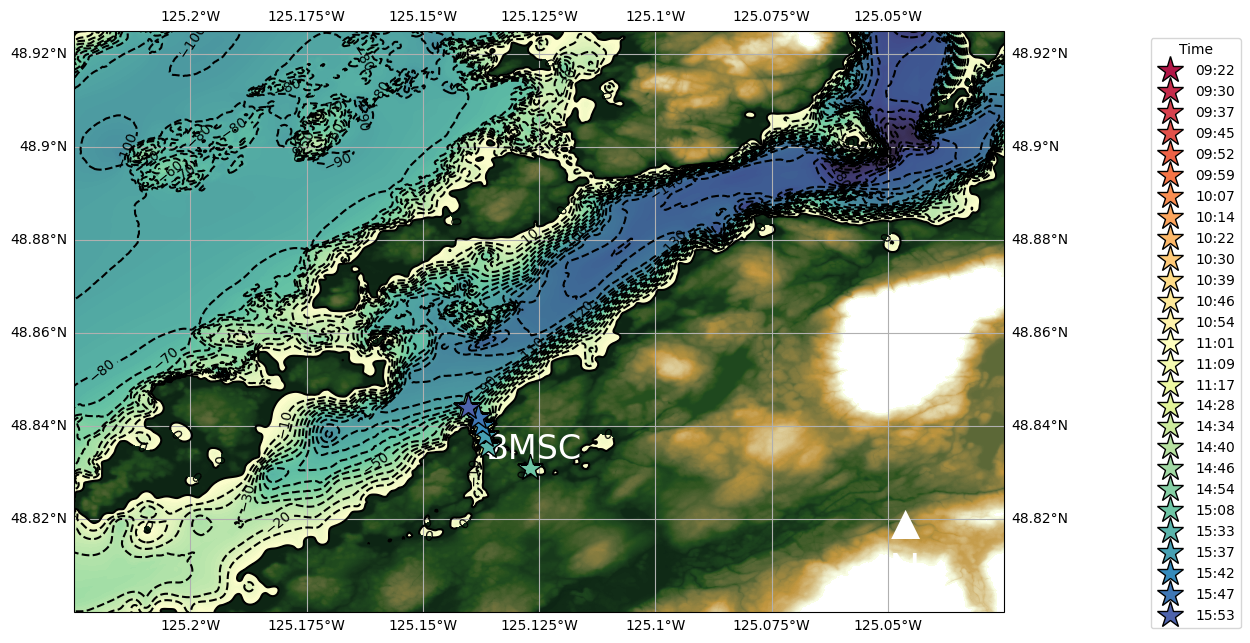

In [36]:
# Load bathymetry dataset
dataset    = netcdf_dataset(BATHY_FILE)
depth_bathy = dataset.variables['Band1'][:, :]
bathy_lats  = dataset.variables['lat'][:]
bathy_lons  = dataset.variables['lon'][:]

map_projection = ccrs.PlateCarree()
fig, ax0 = plt.subplots(figsize=(12, 12), subplot_kw={'projection': map_projection})
ax0.set_extent([-125.225, -125.025, 48.8, 48.925])

# Axis tick formatters
lon_formatter = LongitudeFormatter(zero_direction_label=True)
lat_formatter  = LatitudeFormatter()
ax0.xaxis.set_major_formatter(lon_formatter)
ax0.yaxis.set_major_formatter(lat_formatter)
ax0.gridlines(draw_labels=True)

# BMSC marker (bull's-eye)
BMSC_lat  =  48.8355
BMSC_long = -125.1355
ax0.scatter(BMSC_long, BMSC_lat, s=140, color='k',     transform=ccrs.PlateCarree(), zorder=2)
ax0.scatter(BMSC_long, BMSC_lat, s=90,  color='white', transform=ccrs.PlateCarree(), zorder=2)
ax0.scatter(BMSC_long, BMSC_lat, s=40,  color='k',     transform=ccrs.PlateCarree(), zorder=2)
ax0.text(BMSC_long - 0.001, BMSC_lat - 0.0025, 'BMSC',
         c='white', fontsize=24, transform=ccrs.PlateCarree())

# North arrow
ax0.text(0.9, 0.05, u'▲ \nN ', ha='center', color='white',
         fontsize=30, family='Arial', transform=ax0.transAxes)

# Bathymetry
CS1 = ax0.contourf(bathy_lons, bathy_lats, depth_bathy,
                   levels=np.linspace(-220, 220, 441),
                   cmap=cmocean.cm.topo, transform=ccrs.PlateCarree(), zorder=1)
CS2 = ax0.contour(bathy_lons, bathy_lats, depth_bathy,
                  levels=np.linspace(-220, 0, 23),
                  colors='black', transform=ccrs.PlateCarree(), zorder=2)
ax0.clabel(CS2, CS2.levels)

# Station markers colour-coded by profile index using the shared palette
for i, (lon, lat) in enumerate(zip(sample_lons, sample_lats)):
    if pd.isna(lon) or pd.isna(lat):
        continue
    _lbl = _cast_label(file_list[i], i)
    ax0.plot(lon, lat, '*', color=PROFILE_COLORS[i], markersize=20,
             markeredgecolor='k', transform=ccrs.PlateCarree(), zorder=3,
             label=_lbl)

_legend_title = ('Date / Time' if _multi_date else 'Time') if LABEL_BY_TIME else 'Profile'
ax0.legend(title=_legend_title, bbox_to_anchor=(1.15, 1), loc='upper left', framealpha=0.8)

## CTD Profiles

Each line represents one downcast. The legend label shows the cast time (HH:MM) when `LABEL_BY_TIME = True`, or the profile number when `False` — set in the Configuration cell.

**Measured variables**

| Variable | Description | Units |
|----------|-------------|-------|
| TempCT | In-situ temperature | °C |
| Salinity | Practical salinity (S_P) | PSU |
| DO | Dissolved oxygen | µmol L⁻¹ |
| cDOM | Coloured dissolved organic matter (fluorescence) | ppb |
| pH | pH | — |

**TEOS-10 derived quantities** (computed in the cell above)

| Variable | Description | Units |
|----------|-------------|-------|
| SA | Absolute Salinity | g kg⁻¹ |
| CT | Conservative Temperature | °C |
| σ₀ | Potential density anomaly (ref. 0 dbar) | kg m⁻³ |

> **Smoothing:** the AML-6 samples at 20 Hz, so raw profiles can appear noisy. Set `SMOOTH_WINDOW_S` in the Configuration cell to apply a centered rolling mean before plotting (e.g. `1` for a 1-second window, `0` for no smoothing).

> **Excluding casts:** add profile numbers to `EXCLUDED_PROFILES` in the code cell below to omit specific casts from all plots (e.g. casts with sensor faults or incomplete data).

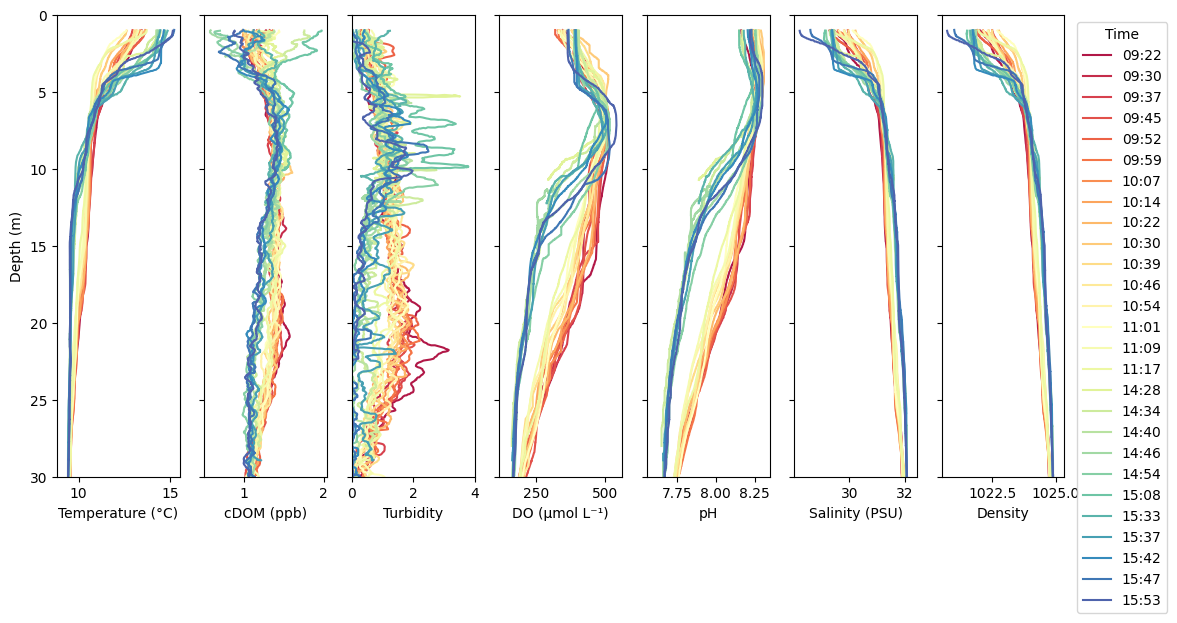

In [39]:
# Profile numbers to exclude from all plots due to data quality issues
# (e.g. sensor malfunction, incomplete cast). Empty by default.
EXCLUDED_PROFILES = []

# Axis labels with units for each measured variable.
# Add or remove entries here when changing which columns are plotted.
AXIS_LABELS = {
    'TempCT':   'Temperature (°C)',
    'Salinity': 'Salinity (PSU)',
    'DO':       DO_LABEL,
    'DOM':      'cDOM (ppb)',
    'pH':       'pH',
    'sigma0':   'σ₀ (kg m⁻³)',
}

# Keep only the measured variables plus Depth and profile.
# Everything else (metadata, TEOS-10 quantities) is dropped before plotting.
# To add sigma0 to the profiles plot, remove it from this list.
data = df.drop(
    ['Date', 'Time', 'Pressure', 'file', 'CalcSV', 'Cond', 'TempDO',
     'Chlorophyll', 'lat', 'lon', 'p', 'SA', 'CT', 'sigma0'],
    axis=1, errors='ignore'
)

# Convert the smoothing window from seconds to samples using the instrument rate.
_smooth_n = int(round(SMOOTH_WINDOW_S * SAMPLE_RATE_HZ))

def _smooth(series):
    if _smooth_n > 1:
        # center=True places the smoothed value at the middle of the window,
        # so features stay at the correct depth rather than being shifted upward.
        # min_periods=1 prevents NaN values at the very top and bottom of a cast.
        return series.rolling(_smooth_n, center=True, min_periods=1).mean()
    return series

# Build the ordered list of variables to plot — everything except the coordinate columns.
_plot_keys = [k for k in data.columns if k not in ('Depth', 'profile')]

fig, axs = plt.subplots(ncols=len(_plot_keys), figsize=(13, 6), sharey=True)
ylim_max = max(data['Depth']) + 0.5
ylim_max = 30   # uncomment and set to fix the maximum depth shown (m)
for ax in axs:
    ax.set_ylim(ylim_max, 0)
axs[0].set_ylabel('Depth (m)')

# groupby('profile') splits df into one chunk per cast.
# zip(axs, _plot_keys) pairs each subplot with the variable it should display,
# avoiding the need for manual index arithmetic.
for ind, CTD in data.groupby('profile'):
    if ind in EXCLUDED_PROFILES:
        continue
    _lbl = _cast_label(file_list[ind], ind)
    for ax, key in zip(axs, _plot_keys):
        if key == 'DO':
            # DO_DIVISOR converts µmol/L → mL/L when DO_UNITS = 'mL/L',
            # and equals 1.0 (no change) when DO_UNITS = 'umol/L'.
            ax.plot(_smooth(CTD['DO'] / DO_DIVISOR), CTD['Depth'],
                    color=PROFILE_COLORS[ind], label=_lbl)
            ax.set_xlabel(AXIS_LABELS['DO'])
        else:
            ax.plot(_smooth(CTD[key]), CTD['Depth'],
                    color=PROFILE_COLORS[ind], label=_lbl)
            ax.set_xlabel(AXIS_LABELS.get(key, key))

# axs[0].set_xlim(9,16)
axs[2].set_xlim(0,4)
# axs[3].set_xlim(170,500)
# axs[4].set_xlim(7.6,8.3)
# axs[5].set_xlim(24,32)
# axs[6].set_xlim(1023.5,1025)

_legend_title = ('Date / Time' if _multi_date else 'Time') if LABEL_BY_TIME else 'Profile'
axs[-1].legend(title=_legend_title, bbox_to_anchor=(1.05, 1), loc='upper left')

# plt.savefig('CTD_25m.png',dpi=300,bbox_inches='tight')

## Multi-variable Profile

The plot below overlays four to six oceanographic variables on a **single depth panel**, each variable on its own colour-coded x-axis stacked above the figure.  
This layout lets you read across variables at any given depth — for example, comparing the depth of the oxygen minimum to the salinity or density structure.

Edit `MULTIAX_VARS` in the code cell to choose which variables to display and in what order. Any variable present in `df` (including TEOS-10 derived quantities such as `sigma0`, `SA`, `CT`) can be used.

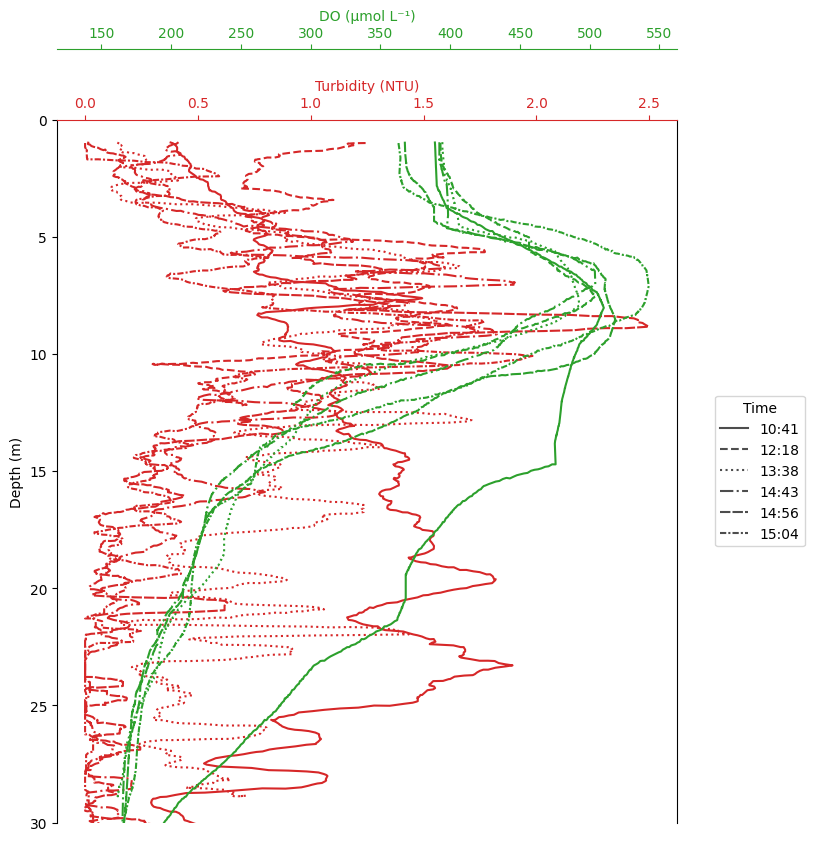

In [94]:
# ── Multi-variable profile plot ──────────────────────────────────────────────
# Each entry: (column name in df,  x-axis label,      axis/line colour).
# Remove entries or add new ones to show 4–6 variables.
MULTIAX_VARS = [
    # ('CT',   'Conservative Temperature (°C)',  'tab:blue'),
    # ('SA', 'Absolute Salinity (g kg$^{-1}$)',    'tab:orange'),
    ('Turbidity', 'Turbidity (NTU)',  'tab:red'),
    # ('DOM',      'cDOM (ppb)',       'tab:cyan'),
    # ('sigma0',   'σ₀ (kg m$^{-3}$)',      'tab:brown'),
    ('DO',       DO_LABEL,           'tab:green'),
    # ('pH',       'pH',               'tab:purple'),
]

# Profiles to include in this plot.
# [] → plot all profiles (minus any in EXCLUDED_PROFILES).
# [0, 2, 5] → plot only profiles 0, 2, and 5.
MULTIAX_PROFILES = [2,22,23,24,25,26] #[0,1,2,3,4]

# Line styles cycled across casts — colour encodes variable, style encodes cast.
CAST_LINESTYLES = ['-', '--', ':', '-.', (0, (5, 1)), (0, (3, 1, 1, 1)),
                   (0, (1, 1)), (0, (5, 1, 1, 1, 1, 1))]

# Skip any variable that doesn't exist in df (e.g. if sensor was absent).
MULTIAX_VARS = [(col, lbl, clr) for col, lbl, clr in MULTIAX_VARS if col in df.columns]

# Smoothing — uses the same SMOOTH_WINDOW_S and SAMPLE_RATE_HZ set in the
# User Configuration cell. Set SMOOTH_WINDOW_S = 0 there to disable smoothing.
_smooth_n_mv = int(round(SMOOTH_WINDOW_S * SAMPLE_RATE_HZ))

def _smooth_mv(series):
    if _smooth_n_mv > 1:
        return series.rolling(_smooth_n_mv, center=True, min_periods=1).mean()
    return series

# Resolve the active profile list: use MULTIAX_PROFILES if specified,
# otherwise fall back to all profiles minus EXCLUDED_PROFILES.
_all = list(range(len(file_list)))
_active_profiles = (
    [i for i in MULTIAX_PROFILES if i not in EXCLUDED_PROFILES]
    if MULTIAX_PROFILES else
    [i for i in _all if i not in EXCLUDED_PROFILES]
)
_style_map = {ind: CAST_LINESTYLES[i % len(CAST_LINESTYLES)]
              for i, ind in enumerate(_active_profiles)}

n_vars  = len(MULTIAX_VARS)
ax_gap  = 0.1   # spacing between successive x-axes in axes-fraction units
_top = 0.1 + 0.87 / (1.0 + (n_vars - 1) * ax_gap)

fig, host = plt.subplots(figsize=(8, 9))
fig.subplots_adjust(top=_top)

twin_axes = [host.twiny() for _ in range(n_vars)]

# Host carries only the y-axis (depth); hide its x-axis completely.
for _sp in ('bottom', 'top'):
    host.spines[_sp].set_visible(False)
host.tick_params(axis='x', which='both',
                 bottom=False, top=False, labelbottom=False, labeltop=False)

for i, (ax, (col, lbl, color)) in enumerate(zip(twin_axes, MULTIAX_VARS)):
    ax.spines['top'].set_position(('axes', 1.0 + i * ax_gap))
    ax.spines['top'].set_visible(True)
    for _s in ('left', 'right', 'bottom'):
        ax.spines[_s].set_visible(False)
    ax.spines['top'].set_color(color)
    ax.tick_params(axis='x', colors=color)
    ax.set_xlabel(lbl, color=color)

    for ind, CTD in df.groupby('profile'):
        if ind not in _active_profiles:
            continue
        _x = _smooth_mv(CTD['DO'] / DO_DIVISOR) if col == 'DO' else _smooth_mv(CTD[col])
        ax.plot(_x, CTD['Depth'], color=color, linestyle=_style_map[ind])

# Shared depth axis — inverted so surface is at the top.
host.set_ylabel('Depth (m)')
ylim_max = df['Depth'].max() + 0.5
ylim_max = 30   # set to fix the maximum depth shown (m); delete line to use full cast depth
host.set_ylim(ylim_max, 0)

# Legend — one entry per cast showing its line style in neutral grey.
_handles = [
    plt.Line2D([0], [0], color='0.3', linestyle=_style_map[ind],
               label=_cast_label(file_list[ind], ind))
    for ind in _active_profiles
]
_legend_title = ('Date / Time' if _multi_date else 'Time') if LABEL_BY_TIME else 'Profile'
host.legend(handles=_handles, title=_legend_title,
            bbox_to_anchor=(1.05, 0.5), loc='center left')

# plt.savefig('CTD_25m_O2.png',dpi=300,bbox_inches='tight')

## Oxygen Saturation

The solubility of oxygen in seawater depends on temperature and salinity: colder, fresher water can hold more dissolved oxygen.  
**Oxygen saturation** expresses the measured concentration as a percentage of the equilibrium solubility at the same T and S:

$$\text{O}_2\% = \frac{[\text{DO}]_\text{measured}}{[\text{DO}]_\text{sat}(T,\, S)} \times 100$$

- $\text{O}_2\% > 100\%$ — **supersaturation**: excess oxygen, typically from photosynthesis near the surface.
- $\text{O}_2\% < 100\%$ — **undersaturation**: oxygen has been consumed, e.g. by respiration or organic matter decomposition.

The saturation concentration is computed using the Garcia & Gordon (1992) equation via `gsw.O2sol_SP_pt`. The dashed line in panel **B** marks 100% saturation.

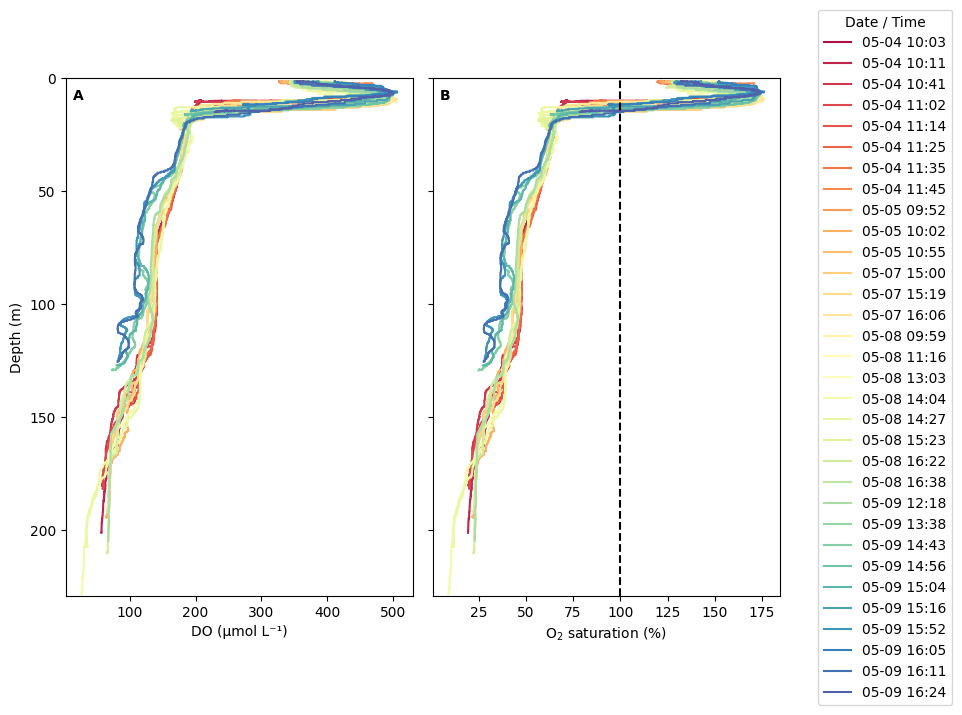

In [16]:
# Potential temperature from TEOS-10 Conservative Temperature
pt = gsw.pt_from_CT(df['SA'], df['CT'])

# O2 saturation in µmol/kg (Garcia & Gordon 1992) using proper potential temperature
o2_sat_umolkg = gsw.O2sol_SP_pt(df['Salinity'], pt)

# Convert to µmol/L using in-situ density from TEOS-10 quantities
rho_kgL      = gsw.rho(df['SA'], df['CT'], df['p']) / 1000
o2_sat_umolL = o2_sat_umolkg * rho_kgL

# Percent saturation (unit-independent)
o2_pct = (df['DO'] / o2_sat_umolL) * 100

# Plot DO profiles alongside percent saturation
fig, axs = plt.subplots(ncols=2, figsize=(8, 6), sharey=True)
ylim_max = max(df['Depth']) + 0.5
for ax in axs:
    ax.set_ylim(ylim_max, 0)
axs[0].set_ylabel('Depth (m)')

for ind, grp in df.groupby('profile'):
    if ind in EXCLUDED_PROFILES:
        continue
    _lbl = _cast_label(file_list[ind], ind)
    axs[0].plot(grp['DO'] / DO_DIVISOR, grp['Depth'], color=PROFILE_COLORS[ind], label=_lbl)
    axs[1].plot(o2_pct[grp.index], grp['Depth'], color=PROFILE_COLORS[ind])

axs[0].set_xlabel(DO_LABEL)
axs[1].set_xlabel('O$_2$ saturation (%)')
axs[1].axvline(100, color='k', linestyle='--')

_legend_title = ('Date / Time' if _multi_date else 'Time') if LABEL_BY_TIME else 'Profile'
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, title=_legend_title, bbox_to_anchor=(1.02, 0.5), loc='center left')
fig.tight_layout()

for ax, lbl in zip(axs, 'AB'):
    ax.text(0.02, 0.98, lbl, transform=ax.transAxes,
            va='top', ha='left', fontweight='bold')

## Apparent Oxygen Utilization (AOU)

**Apparent Oxygen Utilization** is the difference between the saturation concentration and the measured concentration:

$$\text{AOU} = [\text{DO}]_\text{sat}(T,\, S) - [\text{DO}]_\text{measured}$$

- **AOU > 0** — oxygen consumed since last atmospheric contact; signature of net respiration or organic matter remineralisation.  
- **AOU < 0** — oxygen produced in excess of saturation; signature of net photosynthesis.  
- **AOU ≈ 0** — water close to atmospheric equilibrium.

AOU is reported in µmol L⁻¹ regardless of the `DO_UNITS` setting, and the dashed line marks zero.

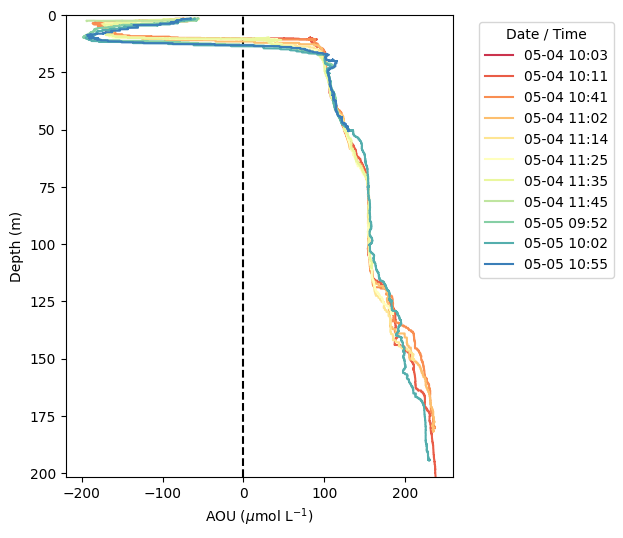

In [280]:
# AOU in µmol/L — always in these units regardless of DO_UNITS setting
aou = o2_sat_umolL - df['DO']

fig, ax = plt.subplots(figsize=(5, 6))
ax.set_ylim(max(df['Depth']) + 0.5, 0)
ax.set_ylabel('Depth (m)')
ax.set_xlabel('AOU ($\\mu$mol L$^{-1}$)')
ax.axvline(0, color='k', linestyle='--')

for ind, grp in df.groupby('profile'):
    if ind in EXCLUDED_PROFILES:
        continue
    _lbl = _cast_label(file_list[ind], ind)
    ax.plot(aou[grp.index], grp['Depth'], color=PROFILE_COLORS[ind], label=_lbl)

_legend_title = ('Date / Time' if _multi_date else 'Time') if LABEL_BY_TIME else 'Profile'
ax.legend(title=_legend_title, bbox_to_anchor=(1.05, 1), loc='upper left')

## Temperature–Salinity (T-S) Diagram

A **T-S diagram** plots temperature against salinity for every data point across all casts.  
Because seawater density depends primarily on these two variables, contours of constant density (**isopycnals**, dashed lines, units: kg m⁻³ − 1000) are overlaid.

- Points falling along the same isopycnal have equal density regardless of their individual temperature and salinity values.
- Distinct water masses appear as clusters; mixing between two water masses appears as a straight line connecting them.
- Colour indicates the variable set by `TS_COLOR`: `'DO'` (dissolved oxygen), `'depth'`, `'Turbidity'`, `'sigma0'` (potential density), `'pH'`, or `'cDOM'`.
- When `TS_MARKER_BY_DAY = True` and multiple dates are loaded, each date is plotted with a distinct marker shape so casts from different days can be distinguished even when they overlap in T-S space.


6.837398577030872 16.923249514625034


Text(0, 0.5, 'Conservative Temperature (°C)')

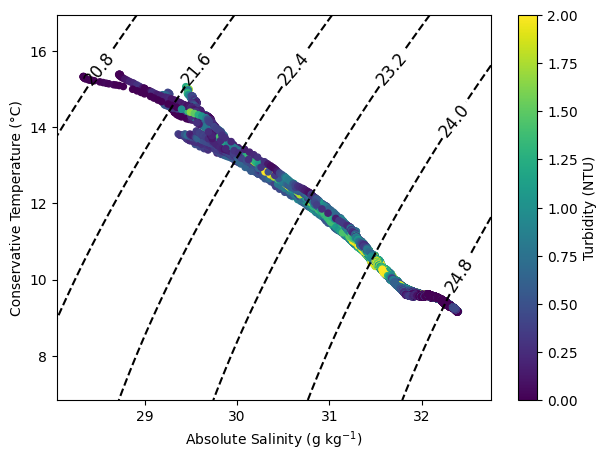

In [67]:
# Exclude profiles with data quality issues
df_ts = df[~df['profile'].isin(EXCLUDED_PROFILES)]

# Calculate boundaries of the T-S space using TEOS-10 quantities
smin = df_ts['SA'].min() - (0.01 * df_ts['SA'].min())
smax = df_ts['SA'].max() + (0.01 * df_ts['SA'].max())
tmin = df_ts['CT'].min() - (0.15 * df_ts['CT'].max())
tmax = df_ts['CT'].max() + (0.1  * df_ts['CT'].max())

print(tmin, tmax)

# Create SA and CT vectors of appropriate dimensions for the density grid
si = np.arange(smin, smax + 0.05, 0.1)
ti = np.arange(tmin, tmax + 0.05, 0.1)

# Compute sigma-0 on a 2-D grid (vectorised)
SI, TI = np.meshgrid(si, ti)
dens = gsw.sigma0(SI, TI)

# Colour variable — controlled by TS_COLOR in the USER CONFIGURATION cell.
if TS_COLOR == 'depth':
    c_var = df_ts['Depth']
    c_lbl = 'Depth (m)'
    c_kw  = {'cmap': cmocean.cm.deep}
elif TS_COLOR == 'Turbidity':
    c_var = df_ts['Turbidity']
    c_lbl = 'Turbidity (NTU)'
    c_kw  = {}
elif TS_COLOR == 'sigma0':
    c_var = df_ts['sigma0']
    c_lbl = 'σ₀ (kg m⁻³)'
    c_kw  = {'cmap': cmocean.cm.dense}
elif TS_COLOR == 'pH':
    c_var = df_ts['pH']
    c_lbl = 'pH'
    c_kw  = {}
elif TS_COLOR == 'cDOM':
    c_var = df_ts['DOM']
    c_lbl = 'cDOM (ppb)'
    c_kw  = {}
else:  # 'DO' or any unrecognised value
    c_var = df_ts['DO'] / DO_DIVISOR
    c_lbl = DO_LABEL
    c_kw  = {}

# Plot
MARKERS  = ['o', 's', '^', 'D', 'v', 'P']
# One perceptually-distinct sequential colormap per day.
# In per-day mode these replace the single TS_COLOR colormap;
# a shared normalisation keeps values comparable across days.
DAY_CMAPS = [cmocean.cm.thermal, cmocean.cm.haline, cmocean.cm.dense,
             cmocean.cm.matter,  cmocean.cm.tempo,  cmocean.cm.ice]

# Map each profile to its date (YYYY-MM-DD) extracted from the filename.
_date_of_profile = {i: os.path.basename(f)[-23:-13] for i, f in enumerate(file_list)}
df_ts['_date'] = df_ts['profile'].map(_date_of_profile)
_dates = sorted(df_ts['_date'].unique())

# Shared normalisation so values are comparable across days.
_norm = plt.Normalize(vmin=float(c_var.min()), vmax=float(c_var.max()))
_norm = plt.Normalize(vmin=0, vmax=2)

fig, ax0 = plt.subplots(figsize=(7,5))
CS = ax0.contour(si, ti, dens, linestyles='dashed', colors='k')
plt.clabel(CS, fontsize=12, inline=1, fmt='%1.1f')

if TS_MARKER_BY_DAY and len(_dates) > 1:
    _marker_map = {d: MARKERS[i % len(MARKERS)]   for i, d in enumerate(_dates)}
    _cmap_map   = {d: DAY_CMAPS[i % len(DAY_CMAPS)] for i, d in enumerate(_dates)}
    _scatters   = {}
    for date, grp in df_ts.groupby('_date'):
        sc = ax0.scatter(grp['SA'], grp['CT'], c=c_var[grp.index],
                         marker=_marker_map[date], cmap=_cmap_map[date],
                         norm=_norm, label=date, s=3)
        _scatters[date] = sc
    for date, sc in _scatters.items():
        fig.colorbar(sc, ax=ax0, label=f'{c_lbl}  [{date}]')
    ax0.legend(title='Date', markerscale=3)
else:
    sc = ax0.scatter(df_ts['SA'], df_ts['CT'], c=c_var, norm=_norm, s=20, **c_kw)
    fig.colorbar(sc, ax=ax0, label=c_lbl)

ax0.set_xlabel('Absolute Salinity (g kg$^{-1}$)')
ax0.set_ylabel('Conservative Temperature (°C)')